# MEDALLIO — Fábrica de Entendimiento, Aprendizaje y Proyección
## Hands-on de Dirección de IA & Analytics

**Propósito:** convertir `medallio_dw` en una fábrica reproducible de decisiones:

> **Observar → Entender → Aprender → Proyectar → Simular → Decidir → Medir**

Este notebook sirve simultáneamente para:

- **Dirección:** identificar cambios, riesgos, oportunidades y decisiones.
- **Analytics / Econometría:** estudiar cohortes, mix, stock, precios, estacionalidad y comparabilidad interproyecto.
- **Machine Learning:** entrenar baselines, segmentar, detectar anomalías y medir desempeño.
- **Forecasting:** evaluar predicciones por horizonte con evidencia prospectiva.
- **MLOps / Gobierno:** vigilar cobertura, drift, backtest y madurez.

### Regla rectora

> **¿Qué sabe Medallio hoy que ayer no sabía, qué decisión cambia por ese aprendizaje y cómo comprobaremos después si la decisión fue mejor?**

---

| Capa | Pregunta | Producto |
|---|---|---|
| Observabilidad | ¿Tengo datos confiables? | cobertura, frescura, nulos, duplicados |
| Entendimiento | ¿Qué pasó y por qué? | EDA, cohortes, mix, absorción |
| Aprendizaje | ¿Qué patrón se repite? | ML, clusters, anomalías |
| Proyección | ¿Qué puede pasar? | forecast, probabilidades, intervalos |
| Escenarios | ¿Qué pasa si…? | simulación de palancas |
| Decisión | ¿Qué hago primero? | prioridad impacto × confianza |
| Gobierno | ¿Sigue siendo confiable? | backtest, drift, monitoring |

# 0. Preparación

Ejecuta este notebook desde `C:\Projects\bd_replica_crm`.

```powershell
cd C:\Projects\bd_replica_crm
.\.venv\Scripts\Activate.ps1
jupyter lab
```

Si faltan librerías, descomenta y ejecuta:

In [ ]:
# %pip install pandas numpy matplotlib scikit-learn "psycopg[binary]" pyarrow openpyxl

# 1. Setup y conexión segura a Medallio

In [ ]:
from __future__ import annotations

import os, re, json, math, warnings
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

RUN_TS = datetime.now(timezone.utc)
ARTIFACT_DIR = Path("artifacts") / "medallio_ai_factory"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("Run UTC:", RUN_TS.isoformat())
print("Artifacts:", ARTIFACT_DIR.resolve())

Run UTC: 2026-10-08T16:07:38.106508+00:00
Artifacts: C:\projects\bd_replica_crm\notebooks\artifacts\medallio_ai_factory


In [ ]:
def find_repo_root(start=None):
    p = (Path(start) if start else Path.cwd()).resolve()
    for candidate in [p, *p.parents]:
        if (candidate / ".git").exists() or (candidate / ".env.example").exists():
            return candidate
    return p

ROOT = find_repo_root()
ENV_PATH = ROOT / ".env"

def load_dotenv_minimal(path):
    if not path.exists():
        return
    for raw in path.read_text(encoding="utf-8").splitlines():
        raw = raw.strip()
        if not raw or raw.startswith("#") or "=" not in raw:
            continue
        k, v = raw.split("=", 1)
        os.environ.setdefault(k.strip(), v.strip().strip('"').strip("'"))

load_dotenv_minimal(ENV_PATH)

DB_CONFIG = {
    "host": os.getenv("POSTGRES_HOST", "localhost"),
    "port": int(os.getenv("POSTGRES_PORT", "5432")),
    "dbname": os.getenv("POSTGRES_DATABASE", "medallio_dw"),
    "user": os.getenv("POSTGRES_USER", "postgres"),
    "password": os.getenv("POSTGRES_PASSWORD", ""),
    "connect_timeout": int(os.getenv("POSTGRES_CONNECT_TIMEOUT", "10")),
}

print("Repo:", ROOT)
print(f"DB: {DB_CONFIG['user']}@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['dbname']}")
print("Password configurado:", bool(DB_CONFIG["password"]))

Repo: C:\projects\bd_replica_crm
DB: postgres@127.0.0.1:5432/medallio_dw
Password configurado: True


In [ ]:
import psycopg

FORBIDDEN_SQL = re.compile(
    r"\\b(insert|update|delete|drop|alter|truncate|create|grant|revoke|copy|call|do)\\b",
    flags=re.I,
)

def get_conn():
    return psycopg.connect(**DB_CONFIG)

def query_df(sql, params=None, read_only=True):
    statement = sql.strip().rstrip(";")
    if read_only and FORBIDDEN_SQL.search(statement):
        raise ValueError("Guardrail read-only: consulta de escritura bloqueada.")
    with get_conn() as conn:
        with conn.cursor() as cur:
            cur.execute(statement, params or ())
            cols = [d.name for d in cur.description] if cur.description else []
            rows = cur.fetchall() if cur.description else []
    return pd.DataFrame(rows, columns=cols)

def safe_relation(name):
    if not re.fullmatch(r"[A-Za-z_][A-Za-z0-9_]*\.[A-Za-z_][A-Za-z0-9_]*", name):
        raise ValueError(f"Relación no permitida: {name}")
    return name

def relation_exists(name):
    schema, rel = safe_relation(name).split(".", 1)
    q = """
    SELECT EXISTS (
        SELECT 1 FROM information_schema.tables
        WHERE table_schema=%s AND table_name=%s
        UNION ALL
        SELECT 1 FROM information_schema.views
        WHERE table_schema=%s AND table_name=%s
    ) AS ok
    """
    return bool(query_df(q, (schema, rel, schema, rel)).iloc[0,0])

display(query_df("SELECT current_database() AS database, now() AS postgres_now"))

,database,postgres_now
0,medallio_dw,2026-10-08 11:07:38.320951-05:00


# 2. Contrato de Inteligencia

Antes de elegir modelos, Medallio comprueba si existen las piezas que permiten **entender → aprender → proyectar → medir**.

,capa,objeto,existe,estado
0,Entendimiento,analytics.fact_evento_comercial,True,OK
1,Entendimiento,analytics.snapshot_unidad_diario,True,OK
2,Entendimiento,analytics.historial_oferta_unidad,True,OK
3,Entendimiento,analytics.historial_etapa_proyecto,True,OK
4,Econometría,analytics.v_econometria_cobertura,True,OK
5,Econometría,analytics.v_econometria_serie_precios,True,OK
6,Econometría,features.v_estacionalidad_panel,True,OK
7,ML,features.v_dataset_unidad_entrenamiento,True,OK
8,ML,features.v_contexto_mercado_por_corte,True,OK
9,Forecast,features.commercial_forecast_snapshots,True,OK


,capa,cobertura_pct
0,Decisión,100.000
1,Econometría,100.000
2,Entendimiento,100.000
3,Forecast,100.000
4,Gobierno,100.000
5,ML,100.000
6,Resultados,100.000


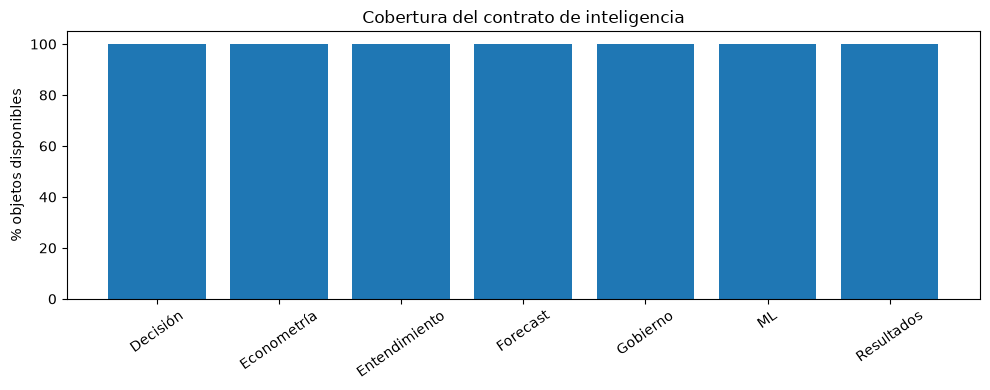

In [ ]:
CONTRACT = [
    ("Entendimiento", "analytics.fact_evento_comercial"),
    ("Entendimiento", "analytics.snapshot_unidad_diario"),
    ("Entendimiento", "analytics.historial_oferta_unidad"),
    ("Entendimiento", "analytics.historial_etapa_proyecto"),
    ("Econometría", "analytics.v_econometria_cobertura"),
    ("Econometría", "analytics.v_econometria_serie_precios"),
    ("Econometría", "features.v_estacionalidad_panel"),
    ("ML", "features.v_dataset_unidad_entrenamiento"),
    ("ML", "features.v_contexto_mercado_por_corte"),
    ("Forecast", "features.commercial_forecast_snapshots"),
    ("Forecast", "model_control.commercial_forecast_runs"),
    ("Forecast", "analytics.commercial_forecast_predictions"),
    ("Forecast", "analytics.commercial_forecast_backtest"),
    ("Forecast", "analytics.v_commercial_forecast_current"),
    ("Forecast", "analytics.v_commercial_forecast_performance"),
    ("Gobierno", "analytics.v_commercial_forecast_coverage"),
    ("Gobierno", "analytics.v_commercial_forecast_monitoring"),
    ("Decisión", "decision_intelligence.commercial_forecast_goals"),
    ("Decisión", "decision_intelligence.commercial_forecast_actions"),
    ("Resultados", "analytics.commercial_forecast_outcomes"),
]

contract_df = pd.DataFrame(CONTRACT, columns=["capa","objeto"])
contract_df["existe"] = contract_df["objeto"].map(relation_exists)
contract_df["estado"] = np.where(contract_df["existe"], "OK", "PENDIENTE")
display(contract_df)

coverage = contract_df.groupby("capa", as_index=False)["existe"].mean()
coverage["cobertura_pct"] = (coverage["existe"]*100).round(1)
display(coverage[["capa","cobertura_pct"]])

fig, ax = plt.subplots(figsize=(10,4))
ax.bar(coverage["capa"], coverage["cobertura_pct"])
ax.set_ylim(0,105)
ax.set_ylabel("% objetos disponibles")
ax.set_title("Cobertura del contrato de inteligencia")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

# 3. Observabilidad: inventario y huella del warehouse

In [ ]:
catalog = query_df("""
SELECT
    n.nspname AS schema_name,
    c.relname AS relation_name,
    CASE c.relkind
        WHEN 'r' THEN 'table'
        WHEN 'p' THEN 'partitioned_table'
        WHEN 'v' THEN 'view'
        WHEN 'm' THEN 'materialized_view'
        ELSE c.relkind::text
    END AS relation_type,
    pg_total_relation_size(c.oid) AS bytes_total,
    pg_size_pretty(pg_total_relation_size(c.oid)) AS size_pretty,
    COALESCE(s.n_live_tup,0) AS estimated_rows
FROM pg_class c
JOIN pg_namespace n ON n.oid=c.relnamespace
LEFT JOIN pg_stat_user_tables s ON s.relid=c.oid
WHERE n.nspname IN (
    'analytics','features','model_control','decision_intelligence',
    'staging','raw_cygnus','raw_mercado'
)
AND c.relkind IN ('r','p','v','m')
ORDER BY pg_total_relation_size(c.oid) DESC
""")

display(catalog.head(50))

schema_summary = (
    catalog.groupby("schema_name", as_index=False)
    .agg(objetos=("relation_name","count"),
         bytes_total=("bytes_total","sum"),
         estimated_rows=("estimated_rows","sum"))
)
schema_summary["GB"] = schema_summary["bytes_total"]/1024**3
display(schema_summary.sort_values("GB", ascending=False))

fig, ax = plt.subplots(figsize=(9,4))
tmp = schema_summary.sort_values("GB", ascending=False)
ax.bar(tmp["schema_name"], tmp["GB"])
ax.set_ylabel("GB")
ax.set_title("Huella de almacenamiento por esquema")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

# 4. Diccionario automático y explorador universal

In [ ]:
dictionary = query_df("""
SELECT table_schema, table_name, ordinal_position, column_name, data_type
FROM information_schema.columns
WHERE table_schema IN ('analytics','features','model_control','decision_intelligence')
ORDER BY table_schema, table_name, ordinal_position
""")
display(dictionary.head(250))
dictionary.to_csv(ARTIFACT_DIR/"diccionario_medallio.csv", index=False)

def columns_of(rel):
    schema, table = safe_relation(rel).split(".",1)
    return query_df("""
        SELECT ordinal_position, column_name, data_type
        FROM information_schema.columns
        WHERE table_schema=%s AND table_name=%s
        ORDER BY ordinal_position
    """, (schema, table))

def inspect_relation(rel, n=8):
    rel = safe_relation(rel)
    if not relation_exists(rel):
        print("⏭ No existe:", rel)
        return None
    print("\n===", rel, "===")
    display(columns_of(rel))
    df = query_df(f"SELECT * FROM {rel} LIMIT {int(n)}")
    display(df)
    return df

for rel in [
    "analytics.v_econometria_cobertura",
    "features.v_estacionalidad_panel",
    "features.v_dataset_unidad_entrenamiento",
    "analytics.v_commercial_forecast_current",
    "analytics.v_commercial_forecast_monitoring",
]:
    inspect_relation(rel, 5)

# 5. Mapa de preguntas de Dirección de IA

Una fábrica de entendimiento necesita explicitar qué preguntas quiere resolver.

In [ ]:
question_map = pd.DataFrame([
    ["Demanda","¿Qué proyectos/tipologías aceleran o desaceleran?","Ritmo, tendencia, cohortes","pricing / marketing / ventas"],
    ["Stock","¿Cuánto stock queda y cuándo podría agotarse?","Cobertura, meses a stock cero","inventario / metas"],
    ["Mix","¿La composición explica diferencias entre proyectos?","mix ajustado","comparabilidad"],
    ["Precio","¿Qué relación hay entre precio/m², descuento y velocidad?","elasticidad / respuesta","pricing"],
    ["Estacionalidad","¿Qué parte del movimiento viene del calendario?","efectos estacionales","metas / forecast"],
    ["Conversión","¿Qué señales anticipan separación/minuta?","probabilidad / lift","priorizar leads"],
    ["Anomalías","¿Qué unidad/proyecto se sale del patrón?","anomaly score","auditoría / oportunidad"],
    ["Forecast","¿Cuánto venderemos por proyecto y horizonte?","P50 / bandas","plan comercial"],
    ["Incertidumbre","¿Qué tan seguro es el forecast?","intervalos / cobertura","riesgo"],
    ["Impacto","¿Qué decisión puede mover más S/?","impacto esperado","recursos"],
    ["Gobierno ML","¿El modelo sigue siendo válido?","drift / backtest / WAPE","recalibrar / retirar"],
], columns=["dominio","pregunta","producto_analitico","decision"])
display(question_map)

# 6. Perfilado de calidad de datos

In [ ]:
def profile_relation(rel, limit=20000):
    rel = safe_relation(rel)
    if not relation_exists(rel):
        return {"objeto":rel, "existe":False}
    df = query_df(f"SELECT * FROM {rel} LIMIT {int(limit)}")
    return {
        "objeto": rel,
        "existe": True,
        "filas_muestra": len(df),
        "columnas": df.shape[1],
        "nulos_pct_promedio": float(df.isna().mean().mean()*100) if len(df) else np.nan,
        "duplicados_fila_pct": float(df.duplicated().mean()*100) if len(df) else np.nan,
    }

profiles = []
for rel in contract_df.loc[contract_df["existe"],"objeto"]:
    try:
        profiles.append(profile_relation(rel))
    except Exception as e:
        profiles.append({"objeto":rel, "existe":True, "error":type(e).__name__})

profiles_df = pd.DataFrame(profiles)

def dq_status(row):
    n = row.get("nulos_pct_promedio", np.nan)
    d = row.get("duplicados_fila_pct", np.nan)
    if pd.isna(n) and pd.isna(d): return "SIN_EVALUAR"
    if (pd.notna(n) and n>35) or (pd.notna(d) and d>10): return "ROJO"
    if (pd.notna(n) and n>15) or (pd.notna(d) and d>3): return "AMBAR"
    return "VERDE"

profiles_df["semaforo"] = profiles_df.apply(dq_status, axis=1)
display(profiles_df)

# 7. Dataset ML: detección automática de roles y targets

In [ ]:
TARGET_HINTS = [
    "target","label","vendido","venta","separacion","minuta","conversion",
    "convirtio","precio_venta","dias_hasta_venta","absorcion","demanda"
]
DATE_HINTS = ["fecha","date","periodo","mes","timestamp","captured_at","created_at"]

def infer_roles(df):
    rows=[]
    n=max(len(df),1)
    for c in df.columns:
        s=df[c]
        lc=c.lower()
        nunique=s.nunique(dropna=True)
        if pd.api.types.is_numeric_dtype(s):
            role="numeric"
        elif pd.api.types.is_datetime64_any_dtype(s) or any(x in lc for x in DATE_HINTS):
            role="date_candidate"
        elif nunique/n>.90:
            role="id_candidate"
        else:
            role="categorical"
        score=max([1 if x==lc else .7 if x in lc else 0 for x in TARGET_HINTS]+[0])
        rows.append({
            "column":c, "dtype":str(s.dtype), "role":role,
            "nunique":nunique, "null_pct":round(float(s.isna().mean()*100),2),
            "target_hint":score
        })
    return pd.DataFrame(rows).sort_values(["target_hint","role"], ascending=[False,True])

TRAIN_REL="features.v_dataset_unidad_entrenamiento"
train_raw=None

if relation_exists(TRAIN_REL):
    train_raw=query_df(f"SELECT * FROM {TRAIN_REL} LIMIT 200000")
    roles=infer_roles(train_raw)
    display(roles)
else:
    print("⏭ Aún no existe", TRAIN_REL)

# 8. EDA hands-on: distribuciones, categorías y correlaciones

In [ ]:
def plot_numeric_distributions(df, max_cols=8):
    for c in df.select_dtypes(include=np.number).columns[:max_cols]:
        s=pd.to_numeric(df[c],errors="coerce").dropna()
        if len(s)<5: continue
        fig,ax=plt.subplots(figsize=(8,3.5))
        ax.hist(s,bins=30)
        ax.set_title(f"Distribución — {c}")
        ax.set_xlabel(c)
        ax.set_ylabel("Frecuencia")
        plt.tight_layout(); plt.show()

def plot_top_categories(df,max_cols=6,top_n=15):
    cats=[c for c in df.columns
          if not pd.api.types.is_numeric_dtype(df[c])
          and df[c].nunique(dropna=True)<=100][:max_cols]
    for c in cats:
        vc=df[c].astype("string").fillna("<NA>").value_counts().head(top_n).sort_values()
        fig,ax=plt.subplots(figsize=(8,4))
        ax.barh(vc.index,vc.values)
        ax.set_title(f"Top categorías — {c}")
        plt.tight_layout(); plt.show()

def plot_correlation_matrix(df,max_cols=15):
    nums=df.select_dtypes(include=np.number)
    if nums.shape[1]<2: return
    var=nums.var(numeric_only=True).sort_values(ascending=False).head(max_cols).index
    corr=nums[var].corr()
    fig,ax=plt.subplots(figsize=(10,8))
    im=ax.imshow(corr.to_numpy(),aspect="auto",vmin=-1,vmax=1)
    ax.set_xticks(range(len(corr.columns)),corr.columns,rotation=90)
    ax.set_yticks(range(len(corr.index)),corr.index)
    ax.set_title("Correlaciones principales")
    fig.colorbar(im,ax=ax)
    plt.tight_layout(); plt.show()

if train_raw is not None and len(train_raw):
    plot_numeric_distributions(train_raw)
    plot_top_categories(train_raw)
    plot_correlation_matrix(train_raw)

# 9. ML supervisado: baseline con disciplina temporal

Selecciona explícitamente el target.

- Clasificación: venta / separación / minuta / conversión.
- Regresión: precio / días a venta / demanda / absorción.

El notebook prefiere un **split temporal** si detecta una fecha utilizable.

In [ ]:
TARGET=None  # Ejemplo: "target_venta"

if train_raw is not None:
    print("Candidatos detectados:")
    display(infer_roles(train_raw).query("target_hint > 0").head(20))
    print("Define TARGET antes de entrenar.")

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.inspection import permutation_importance

def choose_time_column(df):
    candidates=[]
    for c in df.columns:
        if any(x in c.lower() for x in DATE_HINTS):
            parsed=pd.to_datetime(df[c],errors="coerce")
            if parsed.notna().mean()>.60:
                candidates.append((c,parsed.notna().mean()))
    return sorted(candidates,key=lambda x:x[1],reverse=True)[0][0] if candidates else None

def temporal_or_random_split(df,test_size=.2):
    tc=choose_time_column(df)
    if tc:
        t=pd.to_datetime(df[tc],errors="coerce")
        order=np.argsort(t.fillna(pd.Timestamp.min).to_numpy())
        cut=int(len(df)*(1-test_size))
        return order[:cut],order[cut:],f"TEMPORAL:{tc}"
    idx=np.arange(len(df))
    tr,te=train_test_split(idx,test_size=test_size,random_state=42)
    return tr,te,"ALEATORIO_FALLBACK"

print("Motor ML listo.")

In [ ]:
model_bundle=None

if train_raw is None or not len(train_raw):
    print("⏭ Sin dataset de entrenamiento.")
elif TARGET is None:
    print("🟡 Define TARGET.")
elif TARGET not in train_raw.columns:
    print("🔴 El TARGET no existe.")
else:
    df=train_raw.copy()
    y=df[TARGET]
    X=df.drop(columns=[TARGET])

    # Reducir riesgo de memorizar IDs.
    id_like=[c for c in X.columns
             if X[c].nunique(dropna=True)/max(len(X),1)>.98]
    X=X.drop(columns=id_like,errors="ignore")

    # Baseline: quitar fechas crudas. Luego pueden convertirse en features.
    date_like=[c for c in X.columns if any(x in c.lower() for x in DATE_HINTS)]
    X=X.drop(columns=date_like,errors="ignore")

    mask=y.notna()
    X=X.loc[mask].reset_index(drop=True)
    y=y.loc[mask].reset_index(drop=True)

    num_cols=X.select_dtypes(include=np.number).columns.tolist()
    cat_cols=[c for c in X.columns if c not in num_cols]

    prep=ColumnTransformer([
        ("num",Pipeline([("imputer",SimpleImputer(strategy="median"))]),num_cols),
        ("cat",Pipeline([
            ("imputer",SimpleImputer(strategy="most_frequent")),
            ("onehot",OneHotEncoder(handle_unknown="ignore",min_frequency=10))
        ]),cat_cols),
    ])

    unique_y=pd.Series(y).dropna().nunique()
    is_classification=(
        unique_y<=12 and (
            pd.api.types.is_bool_dtype(y)
            or unique_y<=3
            or set(pd.Series(y).dropna().unique()).issubset({0,1,True,False})
        )
    )

    tr,te,split_kind=temporal_or_random_split(X)

    estimator=(
        HistGradientBoostingClassifier(learning_rate=.06,max_iter=250,max_leaf_nodes=31,random_state=42)
        if is_classification else
        HistGradientBoostingRegressor(learning_rate=.06,max_iter=250,max_leaf_nodes=31,random_state=42)
    )

    pipe=Pipeline([("prep",prep),("model",estimator)])
    pipe.fit(X.iloc[tr],y.iloc[tr])
    pred=pipe.predict(X.iloc[te])

    if is_classification:
        prob=pipe.predict_proba(X.iloc[te])[:,1]
        metrics={
            "split":split_kind,
            "n_train":len(tr),"n_test":len(te),
            "roc_auc":roc_auc_score(y.iloc[te],prob) if y.iloc[te].nunique()>1 else np.nan,
            "average_precision":average_precision_score(y.iloc[te],prob) if y.iloc[te].nunique()>1 else np.nan,
            "brier":brier_score_loss(y.iloc[te],prob),
        }
    else:
        actual=pd.to_numeric(y.iloc[te],errors="coerce")
        pred=pd.to_numeric(pd.Series(pred),errors="coerce")
        metrics={
            "split":split_kind,
            "n_train":len(tr),"n_test":len(te),
            "mae":mean_absolute_error(actual,pred),
            "rmse":mean_squared_error(actual,pred)**.5,
            "r2":r2_score(actual,pred),
            "wape":np.abs(actual-pred).sum()/max(np.abs(actual).sum(),1e-9)
        }

    model_bundle={
        "pipeline":pipe,"X":X,"y":y,"train_idx":tr,"test_idx":te,
        "is_classification":is_classification,"metrics":metrics
    }
    display(pd.DataFrame([metrics]))

# 10. Lift de clasificación / residuos de regresión

In [ ]:
if model_bundle and model_bundle["is_classification"]:
    pipe=model_bundle["pipeline"]
    X,y,te=model_bundle["X"],model_bundle["y"],model_bundle["test_idx"]
    prob=pipe.predict_proba(X.iloc[te])[:,1]
    scored=pd.DataFrame({"actual":y.iloc[te].to_numpy(),"score":prob})
    scored["decil"]=pd.qcut(scored["score"].rank(method="first"),10,labels=False)+1
    lift=(scored.groupby("decil",as_index=False)
          .agg(casos=("actual","size"),positivos=("actual","sum"),score_promedio=("score","mean"))
          .sort_values("decil",ascending=False))
    lift["tasa"]=lift["positivos"]/lift["casos"]
    base=scored["actual"].mean()
    lift["lift_vs_base"]=lift["tasa"]/base if base else np.nan
    display(lift)

    fig,ax=plt.subplots(figsize=(8,4))
    ax.bar(lift["decil"].astype(str),lift["lift_vs_base"])
    ax.axhline(1,linestyle="--")
    ax.set_title("Lift por decil")
    ax.set_xlabel("Decil — 10 = score más alto")
    ax.set_ylabel("Lift vs base")
    plt.tight_layout(); plt.show()

elif model_bundle:
    pipe=model_bundle["pipeline"]
    X,y,te=model_bundle["X"],model_bundle["y"],model_bundle["test_idx"]
    pred=pipe.predict(X.iloc[te])
    actual=pd.to_numeric(y.iloc[te],errors="coerce").to_numpy()
    residual=actual-pred

    fig,ax=plt.subplots(figsize=(7,5))
    ax.scatter(pred,residual,alpha=.4)
    ax.axhline(0,linestyle="--")
    ax.set_xlabel("Predicción"); ax.set_ylabel("Residual")
    ax.set_title("Diagnóstico de residuos")
    plt.tight_layout(); plt.show()

else:
    print("⏭ Entrena un modelo primero.")

# 11. Importancia: qué aprendió el modelo

In [ ]:
if model_bundle:
    pipe=model_bundle["pipeline"]
    X,y,te=model_bundle["X"],model_bundle["y"],model_bundle["test_idx"]
    sample=te[-min(len(te),5000):]
    scoring="roc_auc" if model_bundle["is_classification"] and pd.Series(y.iloc[sample]).nunique()>1 else None

    try:
        perm=permutation_importance(
            pipe,X.iloc[sample],y.iloc[sample],
            n_repeats=4,random_state=42,scoring=scoring
        )
        imp=pd.DataFrame({
            "feature":X.columns,
            "importance_mean":perm.importances_mean,
            "importance_std":perm.importances_std
        }).sort_values("importance_mean",ascending=False)
        display(imp.head(30))
        top=imp.head(20).sort_values("importance_mean")
        fig,ax=plt.subplots(figsize=(8,6))
        ax.barh(top["feature"],top["importance_mean"])
        ax.set_title("Importancia por permutación")
        plt.tight_layout(); plt.show()
    except Exception as e:
        print("No se pudo calcular importancia:",e)
else:
    print("⏭ Entrena un modelo primero.")

# 12. No supervisado: segmentación y descubrimiento de regímenes

Útil para detectar grupos de unidades/proyectos que deberían tener reglas comerciales distintas.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler

cluster_result=None

if train_raw is not None and len(train_raw)>=100:
    numeric=train_raw.select_dtypes(include=np.number).copy()
    numeric=numeric.dropna(axis=1,thresh=int(len(numeric)*.6))
    keep=[c for c in numeric.columns
          if numeric[c].nunique(dropna=True)>3
          and numeric[c].nunique(dropna=True)/len(numeric)<.95][:20]

    if len(keep)>=2:
        Z=numeric[keep].replace([np.inf,-np.inf],np.nan)
        Z=Z.fillna(Z.median())
        Zs=RobustScaler().fit_transform(Z)

        ks=list(range(2,min(9,max(3,len(Z)//20+2))))
        inertias=[]
        for k in ks:
            km=KMeans(n_clusters=k,random_state=42,n_init=10).fit(Zs)
            inertias.append(km.inertia_)

        fig,ax=plt.subplots(figsize=(7,4))
        ax.plot(ks,inertias,marker="o")
        ax.set_title("Elección de k — curva de inercia")
        ax.set_xlabel("k"); ax.set_ylabel("Inercia")
        plt.tight_layout(); plt.show()

        K=4 if 4 in ks else ks[-1]
        labels=KMeans(n_clusters=K,random_state=42,n_init=10).fit_predict(Zs)
        cluster_result=Z.copy()
        cluster_result["cluster"]=labels
        display(cluster_result.groupby("cluster")[keep].median().T)
    else:
        print("⏭ Pocas variables apropiadas.")
else:
    print("⏭ Dataset insuficiente.")

# 13. Detección de anomalías

In [ ]:
from sklearn.ensemble import IsolationForest

anomaly_result=None

if train_raw is not None and len(train_raw)>=100:
    numeric=train_raw.select_dtypes(include=np.number).copy()
    numeric=numeric.dropna(axis=1,thresh=int(len(numeric)*.7))
    keep=[c for c in numeric.columns
          if numeric[c].nunique(dropna=True)>5
          and numeric[c].nunique(dropna=True)/len(numeric)<.98][:25]

    if len(keep)>=2:
        Z=numeric[keep].replace([np.inf,-np.inf],np.nan).fillna(numeric[keep].median())
        iso=IsolationForest(n_estimators=300,contamination=.02,random_state=42,n_jobs=-1)
        iso.fit(Z)

        anomaly_result=train_raw.loc[Z.index].copy()
        anomaly_result["anomaly_score"]=-iso.score_samples(Z)
        anomaly_result["es_anomalia"]=iso.predict(Z)==-1
        display(anomaly_result.sort_values("anomaly_score",ascending=False).head(30))
        print("Anomalías:",int(anomaly_result["es_anomalia"].sum()))
    else:
        print("⏭ Pocas variables.")

# 14. Econometría: estacionalidad + edad de proyecto + mix

Modelo conceptual para comparar proyectos de manera justa:

\[
Y_{p,t} = \alpha_p + \beta EdadProyecto_{p,t} + \gamma_{mes(t)} + \delta X_{p,t} + \varepsilon_{p,t}
\]

- `αp`: heterogeneidad propia del proyecto.
- `EdadProyecto`: mes 1, 2, 3… desde inicio comercial.
- `γmes`: efecto calendario.
- `X`: stock, precio, mix, etapa y contexto.

La meta es separar **“este proyecto vende mejor”** de **“este mes suele vender mejor”**.

In [ ]:
SEASON_REL="features.v_estacionalidad_panel"
season_df=None

if relation_exists(SEASON_REL):
    season_df=query_df(f"SELECT * FROM {SEASON_REL} LIMIT 300000")
    display(season_df.head())
    display(infer_roles(season_df))

    likely=[c for c in season_df.select_dtypes(include=np.number).columns
            if any(k in c.lower() for k in ["venta","minuta","separ","absor","ritmo","stock","demanda"])]
    for metric in likely[:4]:
        s=pd.to_numeric(season_df[metric],errors="coerce")
        if s.notna().sum()<10: continue
        fig,ax=plt.subplots(figsize=(9,3.5))
        ax.plot(np.arange(len(s)),s)
        ax.set_title(f"Serie disponible — {metric}")
        ax.set_ylabel(metric)
        plt.tight_layout(); plt.show()
else:
    print("⏭ Aún no existe",SEASON_REL)

# 15. Forecast como evidencia, no como decoración

In [ ]:
FORECAST_CURRENT="analytics.v_commercial_forecast_current"
FORECAST_PERF="analytics.v_commercial_forecast_performance"
FORECAST_MON="analytics.v_commercial_forecast_monitoring"

fc=None
if relation_exists(FORECAST_CURRENT):
    fc=query_df(f"SELECT * FROM {FORECAST_CURRENT}")
    display(fc.head(60))
else:
    print("⏭ Sin forecast actual.")

fm=None
if relation_exists(FORECAST_MON):
    fm=query_df(f"SELECT * FROM {FORECAST_MON}")
    display(fm)
    metrics=[c for c in [
        "strictly_prospective_mae","as_issued_mae","as_issued_bias","as_issued_wape"
    ] if c in fm.columns]
    if "horizon" in fm.columns:
        for metric in metrics:
            fig,ax=plt.subplots(figsize=(7,3.5))
            ax.plot(fm["horizon"],pd.to_numeric(fm[metric],errors="coerce"),marker="o")
            ax.set_title(f"{metric} por horizonte")
            ax.set_xlabel("Horizonte")
            plt.tight_layout(); plt.show()
else:
    print("⏭ Sin monitoring.")

In [ ]:
perf=None
if relation_exists(FORECAST_PERF):
    perf=query_df(f"SELECT * FROM {FORECAST_PERF}")
    display(perf.head(60))

    if {"actual","prediction"}.issubset(perf.columns):
        ev=perf.dropna(subset=["actual","prediction"]).copy()
        if len(ev):
            a=pd.to_numeric(ev["actual"],errors="coerce")
            p=pd.to_numeric(ev["prediction"],errors="coerce")
            scorecard=pd.DataFrame([{
                "n_maduros":len(ev),
                "MAE":np.mean(np.abs(p-a)),
                "RMSE":np.sqrt(np.mean((p-a)**2)),
                "BIAS":np.mean(p-a),
                "WAPE":np.abs(p-a).sum()/max(np.abs(a).sum(),1e-9)
            }])
            display(scorecard)

            fig,ax=plt.subplots(figsize=(6,6))
            ax.scatter(a,p,alpha=.5)
            lo=np.nanmin([a.min(),p.min()])
            hi=np.nanmax([a.max(),p.max()])
            ax.plot([lo,hi],[lo,hi],linestyle="--")
            ax.set_xlabel("Real"); ax.set_ylabel("Pronóstico")
            ax.set_title("Forecast vs resultado")
            plt.tight_layout(); plt.show()
else:
    print("⏭ Sin performance prospectivo.")

# 16. Baselines y challengers

Ningún modelo “gana” por ser sofisticado. Debe superar referencias simples:

- último mes,
- media móvil 3/6 meses,
- mismo mes del año anterior,
- ritmo medio de proyectos comparables por edad.

Métricas recomendadas: **MAE, RMSE, Bias, WAPE y cobertura de intervalos**.

In [ ]:
def forecast_metrics(actual,pred):
    a=pd.Series(actual,dtype="float64")
    p=pd.Series(pred,dtype="float64")
    mask=a.notna() & p.notna()
    a,p=a[mask],p[mask]
    if not len(a): return {}
    return {
        "MAE":float(np.mean(np.abs(p-a))),
        "RMSE":float(np.sqrt(np.mean((p-a)**2))),
        "BIAS":float(np.mean(p-a)),
        "WAPE":float(np.abs(p-a).sum()/max(np.abs(a).sum(),1e-9)),
    }
print("Evaluador challenger listo.")

# 17. Simulador de escenarios para Dirección

Un `what-if` **no es automáticamente causal**. Aquí sirve para expresar sensibilidad y conversación estratégica. Una elasticidad estimada causalmente puede reemplazar luego los supuestos.

In [ ]:
def scenario_grid(base_units,base_price,
                  demand_changes=(-.20,-.10,-.05,0,.05,.10,.20),
                  price_changes=(-.05,-.03,0,.03,.05)):
    rows=[]
    for dq in demand_changes:
        for dp in price_changes:
            units=max(base_units*(1+dq),0)
            price=max(base_price*(1+dp),0)
            rows.append({
                "delta_demanda":dq,"delta_precio":dp,
                "unidades":units,"precio":price,"revenue":units*price
            })
    return pd.DataFrame(rows)

BASE_UNITS=10
BASE_PRICE=500_000

scenarios=scenario_grid(BASE_UNITS,BASE_PRICE)
pivot=scenarios.pivot(index="delta_demanda",columns="delta_precio",values="revenue")
display(pivot.style.format("{:,.0f}"))

fig,ax=plt.subplots(figsize=(8,5))
im=ax.imshow(pivot.values,aspect="auto")
ax.set_xticks(range(len(pivot.columns)),[f"{x:+.0%}" for x in pivot.columns])
ax.set_yticks(range(len(pivot.index)),[f"{x:+.0%}" for x in pivot.index])
ax.set_xlabel("Cambio precio"); ax.set_ylabel("Cambio demanda")
ax.set_title("Sensibilidad de revenue")
fig.colorbar(im,ax=ax)
plt.tight_layout(); plt.show()

# 18. Drift: ¿el presente todavía se parece al pasado?

PSI orientativo:
- `< 0.10`: estable.
- `0.10–0.25`: revisar.
- `> 0.25`: cambio fuerte.

Es una alarma, no prueba por sí sola que el modelo haya fallado.

In [ ]:
def psi_numeric(expected,actual,bins=10):
    e=pd.to_numeric(expected,errors="coerce").dropna()
    a=pd.to_numeric(actual,errors="coerce").dropna()
    if len(e)<30 or len(a)<30: return np.nan
    edges=np.unique(np.quantile(e,np.linspace(0,1,bins+1)))
    if len(edges)<3: return np.nan
    edges[0],edges[-1]=-np.inf,np.inf
    ep=pd.cut(e,bins=edges,include_lowest=True).value_counts(normalize=True,sort=False).clip(lower=1e-6)
    ap=pd.cut(a,bins=edges,include_lowest=True).value_counts(normalize=True,sort=False).clip(lower=1e-6)
    return float(((ap-ep)*np.log(ap/ep)).sum())

def drift_report(df,time_col=None):
    work=df.copy()
    if time_col:
        t=pd.to_datetime(work[time_col],errors="coerce")
        work=work.iloc[np.argsort(t.fillna(pd.Timestamp.min).to_numpy())].reset_index(drop=True)
    cut=int(len(work)*.7)
    old,new=work.iloc[:cut],work.iloc[cut:]
    rows=[{"feature":c,"PSI":psi_numeric(old[c],new[c])}
          for c in work.select_dtypes(include=np.number).columns]
    out=pd.DataFrame(rows).sort_values("PSI",ascending=False)
    out["semaforo"]=pd.cut(out["PSI"],[-np.inf,.10,.25,np.inf],
                           labels=["ESTABLE","REVISAR","CAMBIO_FUERTE"])
    return out

drift=None
if train_raw is not None and len(train_raw)>=200:
    drift=drift_report(train_raw,choose_time_column(train_raw))
    display(drift.head(30))
    top=drift.dropna().head(20).sort_values("PSI")
    if len(top):
        fig,ax=plt.subplots(figsize=(8,6))
        ax.barh(top["feature"],top["PSI"])
        ax.axvline(.10,linestyle="--")
        ax.axvline(.25,linestyle="--")
        ax.set_title("Drift de variables — PSI")
        plt.tight_layout(); plt.show()

# 19. Decision Intelligence: impacto × confianza × urgencia

In [ ]:
decision_queue=pd.DataFrame(columns=[
    "dominio","entidad","senal","impacto_estimado",
    "confianza","urgencia","accion_recomendada","evidencia"
])

# Fila demo; reemplazar por señales reales.
decision_queue.loc[len(decision_queue)]=[
    "Forecast","DEMO","Ritmo esperado debajo de meta",
    250000,.75,.80,
    "Revisar meta, pricing y presión comercial",
    "forecast vs meta"
]

decision_queue["priority_score"]=(
    pd.to_numeric(decision_queue["impacto_estimado"],errors="coerce").fillna(0)
    * pd.to_numeric(decision_queue["confianza"],errors="coerce").fillna(0)
    * pd.to_numeric(decision_queue["urgencia"],errors="coerce").fillna(0)
)

display(decision_queue.sort_values("priority_score",ascending=False))

# 20. Scorecard de madurez de IA

In [ ]:
maturity=pd.DataFrame([
    ["Datos",contract_df.query("capa == 'Entendimiento'")["existe"].mean(),"eventos, snapshots, historiales"],
    ["Econometría",contract_df.query("capa == 'Econometría'")["existe"].mean(),"panel y series"],
    ["Features ML",contract_df.query("capa == 'ML'")["existe"].mean(),"dataset entrenable y contexto"],
    ["Forecast",contract_df.query("capa == 'Forecast'")["existe"].mean(),"predicción + backtest"],
    ["Gobierno",contract_df.query("capa == 'Gobierno'")["existe"].mean(),"cobertura y monitoring"],
    ["Decisión",contract_df.query("capa == 'Decisión'")["existe"].mean(),"metas y acciones"],
    ["Resultados",contract_df.query("capa == 'Resultados'")["existe"].mean(),"outcomes maduros"],
],columns=["dimension","score_0_1","evidencia"])

maturity["score_pct"]=(maturity["score_0_1"].fillna(0)*100).round(0)
display(maturity[["dimension","score_pct","evidencia"]])

fig,ax=plt.subplots(figsize=(9,4))
ax.bar(maturity["dimension"],maturity["score_pct"])
ax.set_ylim(0,105)
ax.set_ylabel("% madurez observable")
ax.set_title("Madurez observable de la fábrica de IA")
ax.tick_params(axis="x",rotation=30)
plt.tight_layout(); plt.show()

# 21. Executive AI Brief automático

In [ ]:
def build_executive_brief():
    missing=contract_df.loc[~contract_df["existe"],"objeto"].tolist()
    present=int(contract_df["existe"].sum())
    total=len(contract_df)
    return {
        "timestamp_utc":RUN_TS.isoformat(),
        "factory_coverage":{
            "objects_present":present,
            "objects_expected":total,
            "coverage_pct":round(100*present/total,1),
        },
        "understanding":{
            "training_dataset_available":bool(relation_exists(TRAIN_REL)),
            "seasonality_panel_available":bool(relation_exists(SEASON_REL)),
        },
        "learning":{
            "model_trained_in_notebook":bool(model_bundle is not None),
            "model_metrics":model_bundle["metrics"] if model_bundle else None,
        },
        "projection":{
            "forecast_current_available":bool(relation_exists(FORECAST_CURRENT)),
            "forecast_performance_available":bool(relation_exists(FORECAST_PERF)),
        },
        "governance":{
            "forecast_monitoring_available":bool(relation_exists(FORECAST_MON)),
            "missing_contract_objects":missing,
        },
        "decisions":decision_queue.sort_values("priority_score",ascending=False).head(10).to_dict("records"),
    }

brief=build_executive_brief()
print(json.dumps(brief,indent=2,ensure_ascii=False,default=str))

(ARTIFACT_DIR/"executive_ai_brief.json").write_text(
    json.dumps(brief,indent=2,ensure_ascii=False,default=str),
    encoding="utf-8"
)

# 22. Export Pack para Power BI, comité y auditoría

In [ ]:
contract_df.to_csv(ARTIFACT_DIR/"contract_status.csv",index=False)
catalog.to_csv(ARTIFACT_DIR/"catalog.csv",index=False)
question_map.to_csv(ARTIFACT_DIR/"question_map.csv",index=False)
profiles_df.to_csv(ARTIFACT_DIR/"data_quality_profiles.csv",index=False)
maturity.to_csv(ARTIFACT_DIR/"ai_maturity.csv",index=False)
decision_queue.to_csv(ARTIFACT_DIR/"decision_queue.csv",index=False)

if drift is not None:
    drift.to_csv(ARTIFACT_DIR/"drift_psi.csv",index=False)
if fc is not None:
    fc.to_csv(ARTIFACT_DIR/"forecast_current.csv",index=False)
if perf is not None:
    perf.to_csv(ARTIFACT_DIR/"forecast_performance.csv",index=False)

print("Export pack:")
for p in sorted(ARTIFACT_DIR.glob("*")):
    print(" -",p)

# 23. Roadmap: de laboratorio a sistema operativo de IA

### Nivel 1 — Entender
- observabilidad y contrato de datos;
- stock, ventas, absorción, mix y pricing;
- comparabilidad por edad de proyecto;
- estacionalidad.

### Nivel 2 — Aprender
- lead scoring;
- propensión de venta por unidad/tipología;
- segmentación;
- anomalías;
- precio/velocidad.

### Nivel 3 — Proyectar
- forecast jerárquico empresa → proyecto → tipología;
- bandas de incertidumbre;
- reconciliación con stock;
- backtesting por horizonte.

### Nivel 4 — Decidir
- metas vs forecast;
- expected shortfall;
- acciones registradas;
- prioridad por impacto × confianza;
- challenger y experimentación.

### Nivel 5 — Aprender de la decisión
- outcome observado;
- uplift e impacto incremental;
- coste de la acción;
- ROI;
- drift y recalibración.

```text
DATOS / CRM / MERCADO
        │
        ▼
 OBSERVABILIDAD
        │
        ▼
 ENTENDIMIENTO
        │
        ▼
   APRENDIZAJE
        │
        ▼
   PROYECCIÓN
        │
        ▼
    DECISIÓN
        │
        ▼
 RESULTADO / LOOP
        └──────────────► vuelve a aprender
```

## Resultado esperado

El objetivo no es tener “muchos modelos”. Es construir una organización capaz de responder:

1. **Qué cambió.**
2. **Por qué creemos que cambió.**
3. **Qué puede ocurrir después.**
4. **Qué decisión tiene mayor valor esperado.**
5. **Cuánta incertidumbre existe.**
6. **Cómo sabremos si la decisión funcionó.**